# DP-SGD on one-hot Criteo

This notebook runs DP-SGD (Abadi et al., *Deep Learning with Differential
Privacy*, 2016, [arXiv:1607.00133](https://arxiv.org/abs/1607.00133)) end to
end on Criteo click-through data: a logistic regression trained for 10,000
steps at ε = 3, δ = 1e-6, with the clipping norm and the learning rate picked
by a nine-point sweep. It exercises the loader, the accountant in both
directions, the training loop and the reference model.

**The encoding is one-hot, and that is what changed.** An earlier execution of
this notebook ran on `load_criteo(features="all")`, where each of `C1..C26` is
collapsed to a single float — the relative frequency of its category in the
training split. That is one column per categorical feature and 39 columns in
all, and it throws away every distinction between two categories that happen to
occur equally often. This notebook runs `load_criteo_one_hot` (ADR-0020)
instead: all 26 categorical columns one-hot at their native train-split
cardinalities, 551,947 coordinates, and a row handed back as the 39 indices it
occupies rather than as a dense vector that would cost 2.2 TB across the file.

Everything else is held at what the frequency-encoded execution used — same
rows, same split seed, same budget, same step count, same expected lot, same
model, same five scores — so the two are readable against each other. The
brackets the sweep searches are not held, and section 4 says why: the clipping
norm is measured against per-sample gradient norms, and those move when the
representation does.

What the encoding is worth, priced properly against a numeric-only arm as well,
is the encoding comparison's subject rather than this one's. This notebook tunes
DP-SGD on the encoding the library now prefers.

In [1]:
import os

# The sweeps below run configurations concurrently on one device and the pool
# is sized against what the allocator will hand out (section 5). JAX reads
# this once, at import, and takes 75% of the device without it. Below the
# bias-reduced-SGD sweep's 0.8 because this card is shared: the fraction is of
# the whole device, so one that assumes an empty device fails at import rather
# than at the first large allocation. Nine gradient blocks and the data fit inside it,
# which is what section 5 checks rather than assumes.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.62")

import time
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.core import gradients, updates
from dimma.core.sampling import poisson
from dimma.datasets.criteo import load_criteo_one_hot
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
    reliability_curve,
)
from dimma.metrics.operating_point import Confusion, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward_sparse, init_params

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# Figure palette. Blue carries the private run and every calibration number
# read off it, orange the noiseless control, aqua the operating-point panel.
# The three clear the colour-vision and normal-vision separation floors as a
# set; aqua sits under 3:1 against white, which is why every point it draws
# is also printed as a table above the figure.
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
PRIVATE_C, CONTROL_C = "#2a78d6", "#eb6834"
LOSS_C = ECE_C = PRIVATE_C
RECALL_C = "#1baf7a"

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


In [2]:
SMOKE = False            # flip to True for a minutes-long shape check

TARGET_DELTA = 1e-6
TARGET_EPSILON = 3.0
STEPS = 10_000
EXPECTED_BATCH_SIZE = 1024

# Fixed before the run, and wider than the frequency-encoded execution's
# (3.5, 4.25, 5.0). Section 4 measures the per-sample gradient norms this
# bracket has to straddle; on this encoding a row's l2 norm is at most about
# 5.2, so the top of the bracket is a clip that binds on nothing and the
# bottom is one that binds on nearly every example.
CLIP_NORMS = (1.0, 2.5, 5.0)
LEARNING_RATES = (0.1, 0.3, 1.0)

# The step grid is shorter than the frequency-encoded execution's nine points.
# A step on 551,947 coordinates costs what a step on 39 does not, and the
# notebook's whole execution has about twenty minutes; five points still
# carry the shape.
STEP_GRID = (50, 200, 1_000, 3_000, 10_000)

FEATURE_NORM_BOUND = None
SEED = 0
N_BINS = 15
PROBE_ROWS = 2_048

if SMOKE:
    STEPS = 50
    CLIP_NORMS, LEARNING_RATES = (2.5,), (0.3,)
    STEP_GRID = (10, 50)
    print("SMOKE: a shape check, not the run this file carries\n")

## 1. Data

Criteo click-through data, all 39 features, with `C1..C26` one-hot at the
cardinalities the training split gives them. The return is a
`SparseTabularSplit`, not a matrix: 39 indices and 39 values a row over a
feature space 551,947 wide. The split is deterministic given `seed` and
`test_fraction` and is cut by the same code as every other Criteo mode, so
these are the same held-out rows the frequency-encoded execution scored on and
the same ones the bias-reduced-SGD comparison and sweep use.

In [3]:
split = load_criteo_one_hot(preprocess=True, download=False, seed=SEED,
                            device=DEVICE,
                            feature_norm_bound=FEATURE_NORM_BOUND
                            )

n_train, stored_per_row = split.idx_train.shape
n_features = split.num_features
base_rate = float(split.y_test.mean())
print(f"train {split.idx_train.shape}   test {split.idx_test.shape}")
print(f"{n_features:,} feature coordinates, {stored_per_row} stored a row")
print(f"label base rate: {float(split.y_train.mean()):.4f} train, "
      f"{base_rate:.4f} test")
print(f"PR-AUC floor (a random ranking scores the base rate): {base_rate:.4f}")

criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point.


train (800000, 39)   test (200000, 39)
551,947 feature coordinates, 39 stored a row
label base rate: 0.2510 train, 0.2520 test
PR-AUC floor (a random ranking scores the base rate): 0.2520


A dimma per-sample loss is `(params, x_single, y_single) -> scalar` and a
training loop slices its `x` along one leading axis, so the two arrays a sparse
row comes in have to travel as one. They are concatenated: the first 39 columns
are the indices, the last 39 the values. Indices go through float32 exactly —
the widest is 551,946, well inside the 16,777,216 where float32 stops counting
by ones — and the assertion below is what says so rather than a comment
claiming it.

The loss is `dimma.models.losses.per_sample_bce_loss` over `forward_sparse`
instead of `forward`: the same model and the same logit, computed from the pair
rather than from the dense row it implies. It is written here rather than
imported because the package's version composes with the dense forward, and
`softplus(z) - z*y` is the same overflow-safe rearrangement the package uses.
This is the bias-reduced-SGD sweep's cell, unchanged, because the two notebooks
are packing the same split for the same loop.

In [4]:
X_TRAIN = jnp.concatenate(
    [split.idx_train.astype(jnp.float32), split.val_train], axis=1
)
assert (np.asarray(X_TRAIN[:, :stored_per_row]).astype(np.int64)
        == np.asarray(split.idx_train)).all(), "index round-trip is not exact"


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values."""
    idx = packed[:stored_per_row].astype(jnp.int32)
    val = packed[stored_per_row:]
    logit = forward_sparse(params, idx, val)
    return jax.nn.softplus(logit) - logit * y


print(f"packed training features {X_TRAIN.shape} {X_TRAIN.dtype}, "
      f"{X_TRAIN.nbytes / 1e6:.0f} MB on {DEVICE}")

packed training features (800000, 78) float32, 250 MB on gpu


The preprocessing statistics — the medians, and the vocabulary each one-hot
block is built from — are fitted on the training split and accounted for in no
privacy budget. The ε reported here covers the training loop and nothing else.

The vocabulary is the larger of the two on this encoding, and it is worth being
plain about what it is: 551,947 columns whose existence and ordering are a
function of which category IDs appeared in the training rows. ADR-0008 records
the caveat and ADR-0020 the reserved slot that keeps a test row with an unseen
category from having nowhere to land.

## 2. Calibrating the budget

`calibrate_noise_multiplier` runs the accountant backwards: given a target
`(ε, δ)` and the shape of the run — the sampling rate `q` over `STEPS` steps —
it returns the smallest noise multiplier that meets the budget. It takes a
*builder*, a function from a candidate multiplier to the release schedules a
run would have at that multiplier, because a method may release on more than
one; plain DP-SGD has exactly one, so the builder returns a single-entry list.

Nothing in this section knows the encoding. `q`, `STEPS` and δ are the whole
input, and 551,947 coordinates cost exactly what 39 did: the Gaussian
mechanism's guarantee is stated per release, not per coordinate, and the
sensitivity clipping enforces is a norm rather than a dimension.

In [5]:
q = EXPECTED_BATCH_SIZE / n_train
print(f"sampling rate q = {q:.6f}, over {STEPS} steps")

t0 = time.time()
sigma = calibrate_noise_multiplier(
    lambda multiplier: [PoissonGaussianSchedule(q, multiplier, STEPS)],
    TARGET_EPSILON, TARGET_DELTA,
)
print(f"noise multiplier sigma = {sigma:.6f}   ({time.time() - t0:.1f}s)")

sampling rate q = 0.001280, over 10000 steps
noise multiplier sigma = 0.682662   (0.2s)


The reporting direction, on the multiplier just calibrated: it should land at
or just under the target. The clipping norm does not enter — clipping makes the
sensitivity `C` and the noise scale `σ · C`, so the ratio the accountant sees is
the same at every `C` — and every run in the sweep below spends exactly this ε.

In [6]:
spent = poisson_gaussian_epsilon(q, sigma, STEPS, TARGET_DELTA)
print(f"epsilon at that multiplier = {spent:.6f}  (target {TARGET_EPSILON})")
assert spent <= TARGET_EPSILON + 1e-9

epsilon at that multiplier = 2.999999  (target 3.0)


## 3. Training, and the operating point

`train` takes a per-sample loss over arbitrary pytrees and never imports the
model, so the model and the algorithm meet only at this call. It returns
neither optimizer state nor a privacy cost: the first would let a caller resume
a run and replay its noise stream from the start, and the second is the
accountant's job.

**The threshold.** At a 25% base rate a calibrated model rarely emits `p > 0.5`
at all, so that cut would report the base rate rather than the classifier.
Every confusion matrix below instead flags a record when the model puts it at
or above the **training-split base rate** — one number, fixed before any run,
and a training-split statistic rather than a further read of the test labels.

**The five numbers.** All of them come from `dimma.metrics`, which carries the
reasoning; the reason for reporting each one here is below.

- **Log-loss** — the objective the loop descends, so selection and training
  agree on what better means.
- **Normalized entropy** — log-loss over the entropy of the base rate, so 1.0
  is the constant predictor and the distance below it is the share of the
  available uncertainty removed (He et al., *Practical Lessons from Predicting
  Clicks on Ads at Facebook*, ADKDD 2014).
- **Calibration ratio** — observed clicks over predicted clicks; 1.0 is
  calibrated, and a bid built on a model at 0.9 overpays by about 11%.
- **ECE**, at 15 equal-mass bins — per-example clipping, not the noise, is the
  documented cause of miscalibration under DP (Zhang et al., *A Closer Look at
  the Calibration of Differentially Private Learners*,
  [arXiv:2210.08248](https://arxiv.org/abs/2210.08248)), which is why the sweep
  below is over `C`. The estimator is biased upward, so these compare only
  against each other.
- **PR-AUC** — the ranking read, floored at the base rate, from
  `dimma.metrics.ranking.pr_curve`. The frequency-encoded execution computed
  this in a cell of its own and noted that the library offered no rank-only
  metric; it does now, and the local helper is gone.

In [7]:
Y_TEST = np.asarray(split.y_test, dtype=np.float64)
THRESHOLD = float(split.y_train.mean())
THRESHOLD_LOGIT = float(np.log(THRESHOLD / (1.0 - THRESHOLD)))
print(f"decision threshold p >= {THRESHOLD:.4f}  "
      f"(logit >= {THRESHOLD_LOGIT:.4f})")

_score = jax.jit(jax.vmap(forward_sparse, in_axes=(None, 0, 0)))

# The padding cap every run below is given, computed here so that `run` can
# pass it explicitly rather than let the loop default it. Section 5 says what
# it costs and why it is not a privacy parameter.
BATCH_CAP = poisson.padded_batch_size(EXPECTED_BATCH_SIZE, n_train)


class Eval(NamedTuple):
    """Everything one run is scored on, plus what drew it."""

    loss: float
    ne: float
    ece: float
    cal_ratio: float
    pr_auc: float
    confusion: Confusion
    """The four counts as `confusion_at` names them, so nothing here
    reads them by position."""
    probs: np.ndarray
    """Kept so the reliability curve does not cost a second training run."""


def evaluate(params):
    """Score one parameter set on the test split.

    The metrics take probabilities, so the logits are squashed once here
    and every number below reads the same array.
    """
    logits = _score(params, split.idx_test, split.val_test)
    probs = np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)
    return Eval(
        loss=log_loss(probs, Y_TEST),
        ne=normalized_entropy(probs, Y_TEST),
        ece=expected_calibration_error(probs, Y_TEST, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, Y_TEST),
        pr_auc=pr_curve(probs, Y_TEST).average_precision,
        confusion=confusion_at(probs, Y_TEST, THRESHOLD),
        probs=probs,
    )


def rates(confusion):
    """Precision and recall (TPR) from a `Confusion`, read by name."""
    flagged = confusion.true_positives + confusion.false_positives
    clicks = confusion.true_positives + confusion.false_negatives
    precision = (confusion.true_positives / flagged if flagged
                 else float("nan"))
    recall = confusion.true_positives / clicks if clicks else float("nan")
    return precision, recall


def show_confusion(confusion, title):
    """The 2x2 as a table -- four numbers do not need a chart."""
    precision, recall = rates(confusion)
    print(f"{title}")
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {confusion.true_negatives:>12,}    "
          f"{confusion.false_positives:>15,}")
    print(f"  actual click   {confusion.false_negatives:>12,}    "
          f"{confusion.true_positives:>15,}")
    print(f"  precision {precision:.4f}   recall {recall:.4f}   "
          f"(at threshold {THRESHOLD:.4f})")


def run(*, steps, clip_norm, learning_rate, noise_multiplier,
        expected_batch_size=EXPECTED_BATCH_SIZE, seed=SEED):
    """One complete DP-SGD run, from a fresh initialization."""
    params = init_params(jax.random.key(0), n_features)
    trained = dp_sgd.train(
        per_sample_sparse_bce, params, updates.sgd(learning_rate),
        X_TRAIN, split.y_train,
        jax.random.key(seed), np.random.default_rng(seed),
        steps=steps, expected_batch_size=expected_batch_size,
        clip_norm=clip_norm, noise_multiplier=noise_multiplier,
        b_max=BATCH_CAP,
    )
    return evaluate(trained)

decision threshold p >= 0.2510  (logit >= -1.0934)


## 4. What the sweep is read against, and where its bracket comes from

Two references. The **constant predictor** ignores the features entirely and
always emits the training base rate; anything scoring worse than it has learned
something worse than nothing, however good its ranking. **The initialization**
is the other, and a private run that scores it has not moved.

The third number below is what fixes `CLIP_NORMS`. Clipping acts on per-sample
gradient norms, so far above them it discards nothing and far below it rescales
every per-sample gradient to the same length — a different update direction,
with no reason to reach the logistic optimum. For this linear model the
per-sample gradient is `(σ(z) − y)·x̄`, so its norm is the augmented row's norm
times a factor in `(0, 1)`, and on this encoding that norm is bounded by the
encoding rather than by the data: 26 categorical ones, 13 integer values in
`[0, log 2]` — the pinned file stores `I1..I13` in `[0, 1]` and `log1p` maps
that interval — and the bias coordinate, so
`sqrt(26 + 13 (log 2)^2 + 1) ≈ 5.77` is the ceiling for every record in the
file. The measurement below is where the norms actually sit inside it.

That is the substantive difference from the frequency-encoded execution, whose
standardized rows ran to a norm of about 16.7 and whose bracket sat at
`(3.5, 4.25, 5.0)`. The same bracket here would sit at or above the largest
gradient the data can produce, and all three columns would be the same
unclipped run.

In [8]:
CONST_PROBS = np.full_like(Y_TEST, THRESHOLD)
CONST_LOSS = log_loss(CONST_PROBS, Y_TEST)
CONST = Eval(
    loss=CONST_LOSS,
    ne=normalized_entropy(CONST_PROBS, Y_TEST),
    ece=expected_calibration_error(CONST_PROBS, Y_TEST, n_bins=N_BINS),
    cal_ratio=calibration_ratio(CONST_PROBS, Y_TEST),
    pr_auc=base_rate,
    confusion=confusion_at(CONST_PROBS, Y_TEST, THRESHOLD),
    probs=CONST_PROBS,
)

START = init_params(jax.random.key(0), n_features)
BEFORE = evaluate(START)

COLUMNS = f"{'log-loss':>9} {'NE':>7} {'ECE':>7} {'cal-ratio':>10} {'PR-AUC':>7}"


def score_row(label, result, width=26):
    """One row of every summary table below, so they share a shape."""
    return (f"{label:<{width}}{result.loss:9.4f} {result.ne:7.4f} "
            f"{result.ece:7.4f} {result.cal_ratio:10.4f} {result.pr_auc:7.4f}")


PER_SAMPLE_GRADS = gradients.per_sample_grads(per_sample_sparse_bce)


@jax.jit
def per_sample_grad_norms(params, x_chunk, y_chunk):
    """Each per-sample gradient's l2 norm, without keeping the block.

    Compiled together so that the dense (B, 551947) gradients are reduced
    as they are produced rather than materialised twice.
    """
    per_sample = PER_SAMPLE_GRADS(params, x_chunk, y_chunk)
    return jnp.sqrt((per_sample["w"] ** 2).sum(1) + per_sample["b"] ** 2)


probe_rows = jax.random.choice(jax.random.key(1), n_train, (PROBE_ROWS,),
                               replace=False)
probe_norms = np.asarray(
    per_sample_grad_norms(START, X_TRAIN[probe_rows], split.y_train[probe_rows])
)

print(f"{'':<26}{COLUMNS}")
print(score_row(f"constant at p = {THRESHOLD:.4f}", CONST))
print(score_row("at initialization", BEFORE))
print(f"\nper-sample gradient l2 norm at the initialization, over "
      f"{len(probe_rows):,} rows: median {np.median(probe_norms):.3f}, "
      f"99th percentile {np.percentile(probe_norms, 99):.3f}, "
      f"max {probe_norms.max():.3f}")
print(f"the bracket this sweep searches: C in {CLIP_NORMS}")

                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant at p = 0.2510       0.5645  1.0000  0.0010     1.0041  0.2520
at initialization            0.7004  1.2407  0.2556     0.4965  0.2635

per-sample gradient l2 norm at the initialization, over 2,048 rows: median 2.638, 99th percentile 2.814, max 2.887
the bracket this sweep searches: C in (1.0, 2.5, 5.0)


## 5. What a step allocates, and how the nine runs share the device

**The memory trap, because it sizes the sweep.** `jax.grad` of a logit that
gathers 40 coordinates still returns a `(551,947,)` row per example, so
per-sample clipping — which is what DP-SGD is for — allocates a dense
`(b_max, 551947)` float32 block. The sparsity buys the data and the forward
pass; it does not buy the gradient buffer (ADR-0020's closing consequence).

`b_max` is the padding cap on a Poisson draw, not a privacy parameter. The draw
has data-dependent cardinality, so the branch pads to a fixed shape, and an
oversize draw **raises** rather than being truncated: truncation would make
inclusion dependent across examples and void the amplification the accountant
assumes (ADR-0007). `run` passes it explicitly rather than letting the loop
default it, so that the block printed below is the block that ran.

**And the nine runs are independent, so they run concurrently in one process on
one device.** Threads change wall-clock and nothing else — every run carries
its own two seeds and its own fresh initialization, so no result can depend on
which of them was in flight when. What the pool size must respect is memory:
each worker holds one gradient block for as long as it runs. The pool is sized
against what the allocator actually has free, which on a shared card is less
than the device's size, and each sweep prints how many ran at once.

In [9]:
BYTES_PER_FLOAT32 = 4
HEADROOM_BYTES = 2 * 1024 ** 3

GRADIENT_BLOCK_BYTES = BATCH_CAP * n_features * BYTES_PER_FLOAT32

stats = jax.devices()[0].memory_stats()
print(f"expected lot {EXPECTED_BATCH_SIZE:,}, padded cap {BATCH_CAP:,}")
print(f"per-sample gradient block: {BATCH_CAP:,} x {n_features:,} float32 = "
      f"{GRADIENT_BLOCK_BYTES / 1e9:.2f} GB a run")
print(f"the allocator will hand out {stats['bytes_limit'] / 1e9:.1f} GB, "
      f"{stats['bytes_in_use'] / 1e9:.1f} GB of it already in use")


def pool_size(n_jobs):
    """Workers whose simultaneous gradient blocks still fit on the device."""
    live = jax.devices()[0].memory_stats()
    free = live["bytes_limit"] - live["bytes_in_use"] - HEADROOM_BYTES
    return max(1, min(n_jobs, int(free // GRADIENT_BLOCK_BYTES)))


def concurrently(jobs):
    """Run one configuration per thread and return the outcomes in order."""
    workers = pool_size(len(jobs))
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        outcomes = list(pool.map(lambda job: run(**job), jobs))
    print(f"{len(jobs)} runs, {workers} at a time, "
          f"{time.time() - t0:.0f}s on {DEVICE}\n")
    return outcomes

expected lot 1,024, padded cap 1,220
per-sample gradient block: 1,220 x 551,947 float32 = 2.69 GB a run
the allocator will hand out 31.5 GB, 0.6 GB of it already in use


## 6. The sweep: `C` against the learning rate

Nine runs, every pair of `C` in `CLIP_NORMS` and learning rate in
`LEARNING_RATES`, all at the same 10,000 steps and the same noise multiplier —
so **every row costs the same ε**, and the table is a utility comparison at a
fixed budget rather than a trade-off curve.

In [10]:
grid = [{"steps": STEPS, "clip_norm": clip_norm,
         "learning_rate": learning_rate, "noise_multiplier": sigma}
        for clip_norm in CLIP_NORMS for learning_rate in LEARNING_RATES]
outcomes = concurrently(grid)
sweep = [(job["clip_norm"], job["learning_rate"], result)
         for job, result in zip(grid, outcomes)]

print(f"{'C':>5} {'lr':>5}  {COLUMNS} {'prec':>7} {'recall':>7}")
for clip_norm, learning_rate, result in sweep:
    precision, recall = rates(result.confusion)
    print(f"{clip_norm:>5} {learning_rate:>5}  "
          f"{result.loss:9.4f} {result.ne:7.4f} {result.ece:7.4f} "
          f"{result.cal_ratio:10.4f} {result.pr_auc:7.4f} "
          f"{precision:7.4f} {recall:7.4f}")
print(f"\neach at epsilon = {spent:.3f}, delta = {TARGET_DELTA}")

E0823 20:34:28.439060 2169144 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


9 runs, 9 at a time, 985s on gpu

    C    lr   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
  1.0   0.1     0.6299  1.1158  0.1628     2.8244  0.4852  0.6348  0.1561
  1.0   0.3     0.6068  1.0749  0.1419     2.2884  0.4984  0.5921  0.2661
  1.0   1.0     0.5884  1.0422  0.1282     1.9587  0.5153  0.5779  0.3406
  2.5   0.1     0.5032  0.8914  0.0546     1.2737  0.5028  0.4767  0.5272
  2.5   0.3     0.4950  0.8769  0.0506     1.2214  0.5191  0.4782  0.5610
  2.5   1.0     0.4981  0.8824  0.0542     1.1866  0.5240  0.4761  0.5763
  5.0   0.1     0.4858  0.8605  0.0089     0.9867  0.5117  0.4152  0.7019
  5.0   0.3     0.4827  0.8550  0.0082     0.9697  0.5190  0.4173  0.7069
  5.0   1.0     0.5076  0.8992  0.0443     1.0040  0.4887  0.4154  0.6446

each at epsilon = 3.000, delta = 1e-06


The best of the nine **by log-loss**, with its confusion matrix, beside the
same configuration with the noise switched off (`noise_multiplier = 1e-8`).
Selection is on the proper score rather than on the ranking because clipping is
what damages calibration, so the ranking is the half of the model least likely
to have moved — PR-AUC is reported, not obeyed.

That control is **not** a non-private baseline in the sense ADR-0005 means: it
still clips every per-sample gradient and still samples by Poisson. What it
isolates is the cost of the noise alone.

In [11]:
BEST_C, BEST_LR, best = min(sweep, key=lambda row: row[2].loss)
print(f"best by log-loss: C = {BEST_C}, lr = {BEST_LR}\n")

ctrl = run(steps=STEPS, clip_norm=BEST_C, learning_rate=BEST_LR,
           noise_multiplier=1e-8)

print(f"{'':<26}{COLUMNS}")
print(score_row("constant / PR-AUC floor", CONST))
print(score_row("at initialization", BEFORE))
print(score_row(f"at epsilon = {spent:.3f}", best))
print(score_row("no noise (control)", ctrl))
print()
show_confusion(best.confusion, f"C = {BEST_C}, lr = {BEST_LR}, {STEPS:,} "
                               f"steps, epsilon = {spent:.3f}")
print()
show_confusion(ctrl.confusion, f"C = {BEST_C}, lr = {BEST_LR}, {STEPS:,} "
                               f"steps, no noise (control)")

best by log-loss: C = 5.0, lr = 0.3



                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant / PR-AUC floor      0.5645  1.0000  0.0010     1.0041  0.2520
at initialization            0.7004  1.2407  0.2556     0.4965  0.2635
at epsilon = 3.000           0.4827  0.8550  0.0082     0.9697  0.5190
no noise (control)           0.4783  0.8472  0.0103     0.9609  0.5287

C = 5.0, lr = 0.3, 10,000 steps, epsilon = 3.000
                 predicted no    predicted click
  actual no            99,844             49,756
  actual click         14,773             35,627
  precision 0.4173   recall 0.7069   (at threshold 0.2510)

C = 5.0, lr = 0.3, 10,000 steps, no noise (control)
                 predicted no    predicted click
  actual no            98,933             50,667
  actual click         13,866             36,534
  precision 0.4190   recall 0.7249   (at threshold 0.2510)


### Reading the nine rows

**Three of the nine score worse than the constant predictor, and they still
rank with the rest.** The whole `C = 1.0` column sits at log-loss 0.6299,
0.6068 and 0.5884 against the constant's 0.5645 — worse than emitting the base
rate and never looking at a feature — while its PR-AUC runs 0.4852 to 0.5153,
which is twice the 0.2520 floor and, at its top, within a hundredth of the
best ranker's 0.5240. The calibration column says what happened: 2.8244,
2.2884, 1.9587, so those models under-predict clicks by a factor of two to
three, and their ECE is 0.16, 0.14,
0.13. Clipping every per-sample gradient to a third of its length does not stop
the model telling records apart; it stops the model saying how often. That is
Zhang et al.'s finding on this dataset, and it is the reason this sweep is over
`C` and reads a proper score rather than a ranking.

**`C` is the axis that matters, and the learning rate is not inert.** Log-loss
falls 0.6299 → 0.5032 → 0.4858 as `C` goes 1.0 → 2.5 → 5.0 at `lr = 0.1`, and
ECE falls 0.1628 → 0.0546 → 0.0089 along the same column. The learning rate,
which the frequency-encoded execution found nearly inert, interacts here: at
`C = 1.0` a larger rate helps (0.6299 → 0.5884, because a clipped gradient is
short and needs a longer step), and at `C = 5.0` the largest rate overshoots
(0.4827 → 0.5076). `lr = 0.3` wins and is interior to its axis.

**The winner is at the top of the `C` bracket, and this time that edge is
nearly a wall.** `C = 5.0` sits within 14% of `sqrt(26 + 13 (log 2)^2 + 1)`,
the largest per-sample gradient norm this encoding can produce, so a wider
bracket has very little room to explore: above 5.77 every `C` is the same
unclipped run. The frequency-encoded execution ended on the same edge with its
log-loss still descending and no such ceiling to appeal to.

**Selection gives up a little ranking, as it is designed to.** The best row by
log-loss (`C = 5.0, lr = 0.3`, PR-AUC 0.5190) is not the best ranker: `C = 2.5,
lr = 1.0` reaches 0.5240 at log-loss 0.4981. The nine PR-AUCs span 0.4852 to
0.5240 on one seed, so the ranking does not separate them; `C` separates them
on calibration, where ECE spans a factor of twenty.

**The noise now costs something, and the clipping still costs more.** The
noiseless control reaches log-loss 0.4783 and PR-AUC 0.5287 against the private
run's 0.4827 and 0.5190 — so the calibrated multiplier costs 0.0044 of log-loss
and 0.0097 of PR-AUC, where on the frequency encoding it cost nothing
measurable. That is the dimension arriving: the same multiplier now perturbs
551,947 coordinates instead of 39. It is still the smaller of the two costs —
moving `C` from 1.0 to 5.0 is worth 0.15 of log-loss, thirty times as much.

**And the encoding is worth more than either.** At this same budget, this same
step count and this same notebook, the frequency-encoded execution reached
log-loss 0.5140 and PR-AUC 0.4460. One-hot reaches 0.4827 and 0.5190. The
0.0730 of PR-AUC between them is seven times what the noise costs here and
larger than the entire gap between this private run and its noiseless control.
The encoding comparison prices that properly, against a numeric-only arm as well
and with each encoding tuned on validation rather than compared across two
executions.

### Where the probabilities land

ECE collapses this figure to one number; this is the figure. Each point is an
equal-mass bin of the test split: what the model said on the horizontal, what
happened on the vertical, with over-prediction below the diagonal and
under-prediction above it. The private run and the noiseless control are drawn
together because whether they leave the diagonal together is the question.

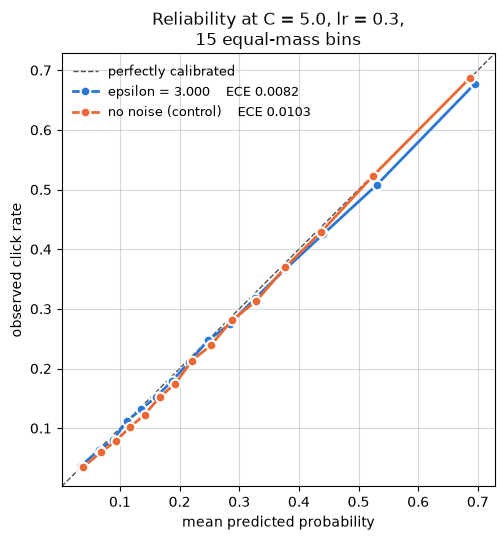

private: 15 bins kept, 13,333-13,334 records each, largest gap 0.0227
control: 15 bins kept, 13,333-13,334 records each, largest gap 0.0185


In [12]:
best_curve = reliability_curve(best.probs, Y_TEST, n_bins=N_BINS)
ctrl_curve = reliability_curve(ctrl.probs, Y_TEST, n_bins=N_BINS)

points = np.concatenate([best_curve.mean_predicted, best_curve.mean_observed,
                         ctrl_curve.mean_predicted, ctrl_curve.mean_observed])
pad = 0.05 * (points.max() - points.min())
lo, hi = points.min() - pad, points.max() + pad

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color=MUTED,
        zorder=1, label="perfectly calibrated")

# Identity is in the legend rather than at the end of each line: the two
# curves are expected to sit close to each other, which is where a direct
# label stops being readable.
for reliability, colour, label in (
    (best_curve, PRIVATE_C, f"epsilon = {spent:.3f}    ECE {best.ece:.4f}"),
    (ctrl_curve, CONTROL_C, f"no noise (control)    ECE {ctrl.ece:.4f}"),
):
    ax.plot(reliability.mean_predicted, reliability.mean_observed, marker="o",
            markersize=7, linewidth=2, color=colour, label=label,
            markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=2)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed click rate")
ax.set_title(f"Reliability at C = {BEST_C}, lr = {BEST_LR},\n"
             f"{N_BINS} equal-mass bins", color=INK)
ax.grid(alpha=0.5)
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"private: {len(best_curve.count)} bins kept, "
      f"{best_curve.count.min():,}-{best_curve.count.max():,} records each, "
      f"largest gap {np.abs(best_curve.gap).max():.4f}")
print(f"control: {len(ctrl_curve.count)} bins kept, "
      f"{ctrl_curve.count.min():,}-{ctrl_curve.count.max():,} records each, "
      f"largest gap {np.abs(ctrl_curve.gap).max():.4f}")

## 7. The best configuration over training steps

Hold `C`, the learning rate and the noise multiplier at the values section 6
picked, and vary only how long the run trains; log-loss, ECE and recall are on
three scales, so they get a panel each. **Each point is an independent run**
from the same initialization with its own noise draw — `train` returns no
optimizer state precisely so that a run cannot be resumed and replay its noise
stream.

The multiplier stays the one calibrated for 10,000 steps, so the shorter runs
are *over*-noised for their length and spend correspondingly less ε. The ε each
point actually spends is in the table.

In [13]:
lengths = [{"steps": steps, "clip_norm": BEST_C, "learning_rate": BEST_LR,
            "noise_multiplier": sigma} for steps in STEP_GRID]
length_outcomes = concurrently(lengths)
curve = [(steps, poisson_gaussian_epsilon(q, sigma, steps, TARGET_DELTA),
          result)
         for steps, result in zip(STEP_GRID, length_outcomes)]

print(f"{'steps':>7} {'epsilon':>8}  {COLUMNS} {'prec':>7} {'recall':>7}")
for steps, eps, result in curve:
    precision, recall = rates(result.confusion)
    print(f"{steps:>7,} {eps:>8.3f}  "
          f"{result.loss:9.4f} {result.ne:7.4f} {result.ece:7.4f} "
          f"{result.cal_ratio:10.4f} {result.pr_auc:7.4f} "
          f"{precision:7.4f} {recall:7.4f}")

5 runs, 5 at a time, 144s on gpu

  steps  epsilon   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
     50    2.075     0.5376  0.9524  0.0511     0.9820  0.4068  0.3436  0.7061
    200    2.182     0.5146  0.9116  0.0344     0.9578  0.4542  0.3659  0.7226
  1,000    2.360     0.4954  0.8775  0.0145     0.9737  0.4900  0.3980  0.7073
  3,000    2.563     0.4882  0.8649  0.0068     0.9819  0.5058  0.4112  0.7014
 10,000    3.000     0.4827  0.8550  0.0082     0.9697  0.5190  0.4173  0.7069


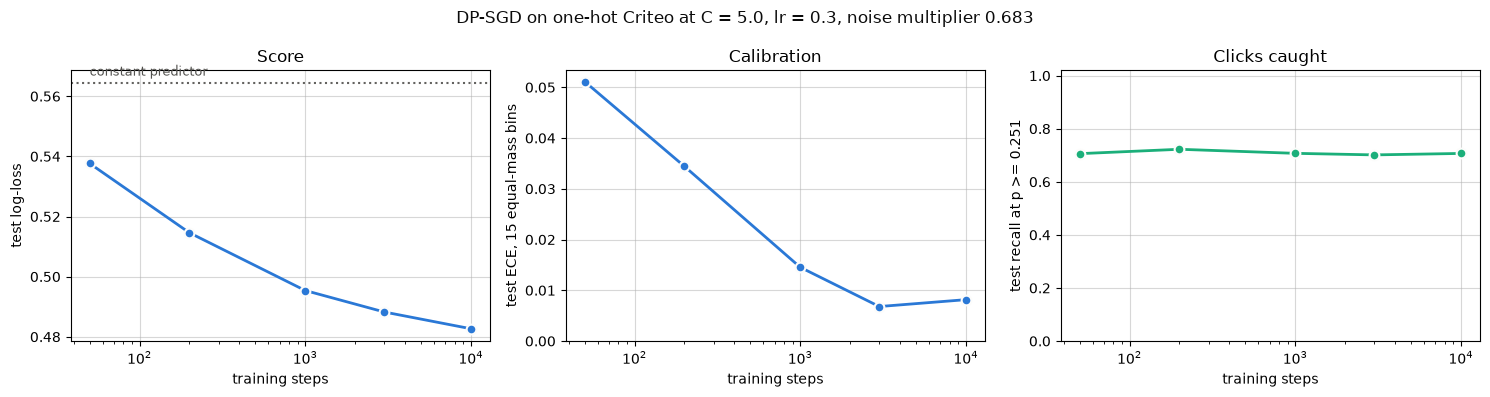

In [14]:
steps_axis = [point[0] for point in curve]
results = [point[2] for point in curve]

fig, (left, middle, right) = plt.subplots(1, 3, figsize=(15, 4))

left.plot(steps_axis, [r.loss for r in results], marker="o", markersize=7,
          linewidth=2, color=LOSS_C, markeredgecolor=SURFACE,
          markeredgewidth=1.5)
left.axhline(CONST_LOSS, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("constant predictor", xy=(steps_axis[0], CONST_LOSS),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
left.set_ylabel("test log-loss")
left.set_title("Score")

# ECE is an upward-biased estimate, so the distance from zero is not a
# calibration error and only the movement across this panel is readable --
# every point is the same n_bins on the same evaluation set.
middle.plot(steps_axis, [r.ece for r in results], marker="o", markersize=7,
            linewidth=2, color=ECE_C, markeredgecolor=SURFACE,
            markeredgewidth=1.5)
middle.set_ylabel(f"test ECE, {N_BINS} equal-mass bins")
middle.set_title("Calibration")
middle.set_ylim(bottom=0.0)

right.plot(steps_axis, [rates(r.confusion)[1] for r in results], marker="o",
           markersize=7, linewidth=2, color=RECALL_C,
           markeredgecolor=SURFACE, markeredgewidth=1.5)
right.set_ylabel(f"test recall at p >= {THRESHOLD:.3f}")
right.set_title("Clicks caught")
# A rate gets its own scale. Autoscaling this panel would fill the frame with
# the seed-to-seed wobble in the converged tail and draw it as a trend.
right.set_ylim(0.0, 1.02)

for axis in (left, middle, right):
    axis.set_xlabel("training steps")
    axis.set_xscale("log")
    axis.grid(alpha=0.5)

fig.suptitle(f"DP-SGD on one-hot Criteo at C = {BEST_C}, lr = {BEST_LR}, "
             f"noise multiplier {sigma:.3f}", color=INK)
fig.tight_layout()
plt.show()

### Reading those three panels

**The run is not finished at 10,000 steps, and on the frequency encoding it
was finished by 2,000.** Log-loss goes 0.5376 → 0.5146 → 0.4954 → 0.4882 →
0.4827 across 50, 200, 1,000, 3,000 and 10,000 steps: the last stretch, from
3,000 to 10,000, is still worth 0.0055 of log-loss and 0.0132 of PR-AUC
(0.5058 → 0.5190). The frequency-encoded execution moved in the fourth decimal
over the same stretch and its closing said the later steps bought little. There
are 551,947 weights here against 40, and most of them are touched by a small
fraction of the rows, so the run has more to do and takes longer to do it.

**So the ε those steps cost is now buying something.** ε climbs 2.563 → 3.000
from 3,000 steps to 10,000, and unlike the frequency-encoded execution that
purchase is visible in both panels rather than in neither. The caveat that
notebook carried still applies in the other direction: the multiplier is
calibrated for 10,000 steps, so every shorter row is over-noised for its length
and a run actually targeting ε = 2.563 would use a smaller multiplier and land
above its point here.

**Calibration bottoms out before the score does.** ECE reaches 0.0068 at 3,000
steps and rises to 0.0082 by 10,000 while log-loss keeps falling — the last
7,000 steps buy resolution and give back a little calibration. The panel's
scale makes that look larger than it is: both numbers are inside the band where
this upward-biased estimator is only comparable to itself.

**Recall is flat and precision is what improves.** Recall holds between 0.7014
and 0.7226 across a two-hundredfold change in run length while precision climbs
0.3436 → 0.4173. At the base-rate threshold this model settles early on how
many records to flag and spends the rest of the run getting better at which
ones — which is the same movement the log-loss panel shows, read at one
operating point.

## What this shows, and what it does not

DP-SGD end to end on 800,000 real Criteo rows and all 39 features, one-hot into
551,947 coordinates: the loader, the accountant in both directions (calibrate,
then report, agreeing to floating point), the training loop, the reference model
and its sparse forward.

At ε = 3, δ = 1e-6 over 10,000 steps, the selected configuration — `C = 5.0`,
`lr = 0.3` — reaches test log-loss 0.4827 against the constant predictor's
0.5645, normalized entropy 0.8550, ECE 0.0082, calibration ratio 0.9697, and
PR-AUC 0.5190 against a base-rate floor of 0.2520. The noiseless control reaches
0.4783 and 0.5287, so at this budget the noise costs 0.0044 of log-loss and
0.0097 of PR-AUC and the clipping costs more. At the base-rate threshold the
private model catches 35,627 of the 50,400 test clicks and raises 49,756 false
alarms.

**Against the frequency encoding, at the same budget and step count**, that is
log-loss 0.5140 → 0.4827 and PR-AUC 0.4460 → 0.5190. This notebook is not the
place that claim gets tested — it is a comparison across two executions with
different clip brackets, and its own sweep was selected on the test split.
The encoding comparison runs the three encodings side by side under one
protocol.

Not shown, and not claimed:

- One algorithm, and no non-private baseline. The control clips and samples
  exactly as the private arm does; it is the noise switched off, not ADR-0005's
  baseline.
- **The preprocessing statistics are unaccounted** (ADR-0008), and on this
  encoding the larger of them is the vocabulary: 551,947 columns whose
  existence and order are a function of the training rows. The ε above covers
  the training loop only.
- **The nine-run search is unaccounted**, and its winner was picked on the test
  split, so the reported figures are optimistic as held-out estimates as well
  as unpaid for as a privacy matter.
- **The operating point is a choice.** Every confusion matrix thresholds at the
  training base rate; a different threshold gives different precision and
  recall from the same model, while the ranking does not move.
- **No feature-norm bound.** Nothing caps row norms here, which is available
  only because clipping is what bounds DP-SGD's sensitivity. What bounds them
  instead is the encoding, at 5.77, and that is arithmetic rather than a
  measurement.
- **The winner sits at the top of the `C` bracket.** The ceiling above it is
  0.77 wide, so the unexplored room is small — but it is not zero.
- **One seed.** Every run above is `seed=0`, so none of the gaps come with an
  error bar, and the 0.0097 the noise costs is the size of gap a second seed
  could move.
- **The ε is RDP's** (ADR-0011); PLD would report a smaller number for the same
  run.